# Visualization for Option Greeks

This notebook explores the behavior of the five main option Greeks (**Delta**, **Theta**, **Gamma**, **Vega**, and **Rho**) and their relationships with key parameters (Stock price, Strike price, Time to Maturity, Volatility, Risk-Free Rate, and Dividend Yield). The analysis is organized into three sections:

1. **Single-Parameter Variation:** Plot each Greek as a function of one varying parameter.
2. **Multi-Panel 2D Contours:** Display the Greeks as 2D contour plots for combinations of two parameters:
   - Stock Price ($S$) vs Time to Maturity ($T$)
   - Stock Price ($S$) vs Volatility ($\sigma$)
   - Stock Price ($S$) vs Risk-Free Rate ($r$)
3. **Greeks vs Greeks:** Show the interplay between Greeks as the stock price varies.

## Option Greeks Summary (European Options)

| Greek  | Call Option | Put Option | Definition |
|--------|------------|-----------|------------|
| **Delta ($\Delta$)** | $\Delta_{\rm call} = e^{-q T} N(d_1)$ | $\Delta_{\rm put} = - e^{-q T} N(-d_1)$ | Sensitivity of option price to changes in the underlying stock price |
| **Gamma ($\Gamma$)** | $\Gamma = \frac{e^{-q T} N'(d_1)}{S \sigma \sqrt{T}}$ | Same as call | Rate of change of Delta with respect to the stock price |
| **Theta ($\Theta$)** | $\Theta_{\rm call} = - \frac{S \sigma e^{-q T} N'(d_1)}{2 \sqrt{T}} - r K e^{-r T} N(d_2) + q S e^{-q T} N(d_1)$ | $\Theta_{\rm put} = - \frac{S \sigma e^{-q T} N'(d_1)}{2 \sqrt{T}} + r K e^{-r T} N(-d_2) - q S e^{-q T} N(-d_1)$ | Sensitivity of option price to the passage of time (time decay) |
| **Vega ($\nu$)** | $\text{Vega} = S e^{-q T} N'(d_1) \sqrt{T}$ | Same as call | Sensitivity of option price to changes in volatility |
| **Rho ($\rho$)** | $\rho_{\rm call} = K T e^{-r T} N(d_2)$ | $\rho_{\rm put} = - K T e^{-r T} N(-d_2)$ | Sensitivity of option price to changes in the risk-free interest rate |

**Where:**  
$$
d_1 = \frac{\ln(S/K) + (r - q + \frac{1}{2}\sigma^2) T}{\sigma \sqrt{T}}, \quad
d_2 = d_1 - \sigma \sqrt{T}
$$  

> $N(\cdot)$ is the standard normal CDF and $N'(\cdot)$ is the PDF. Gamma and Vega are identical for calls and puts.

---

## Import Packages and Functions

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import LogNorm, SymLogNorm

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import BSM_pricing
from greeks import delta, theta, gamma, vega, rho

## 1.1 Delta Variation

This subsection illustrates the behavior of **Delta** for European call and put options. We present two complementary plots side by side:

**Left Panel: Variation with Stock Price \($S$\)**  
- Shows Delta as a function of the underlying stock price for both call and put options.  
  - Fixed parameters: Strike price \($K$\), risk-free rate \($r$\), volatility \($\sigma$\), and time to maturity \($T$\).  
- Highlights how Delta approaches 1 for deep ITM calls, 0 for deep OTM calls, and conversely for put options.  

**Right Panel: Variation with Time to Maturity \($T$\)**  
- Shows Delta for call options at three levels of moneyness:  
  - **ITM:** \($S > K$\)  
  - **ATM:** \($S = K$\)  
  - **OTM:** \($S < K$\)  
- Illustrates how Delta evolves as the option approaches expiration, depending on how far in- or out-of-the-money it is.


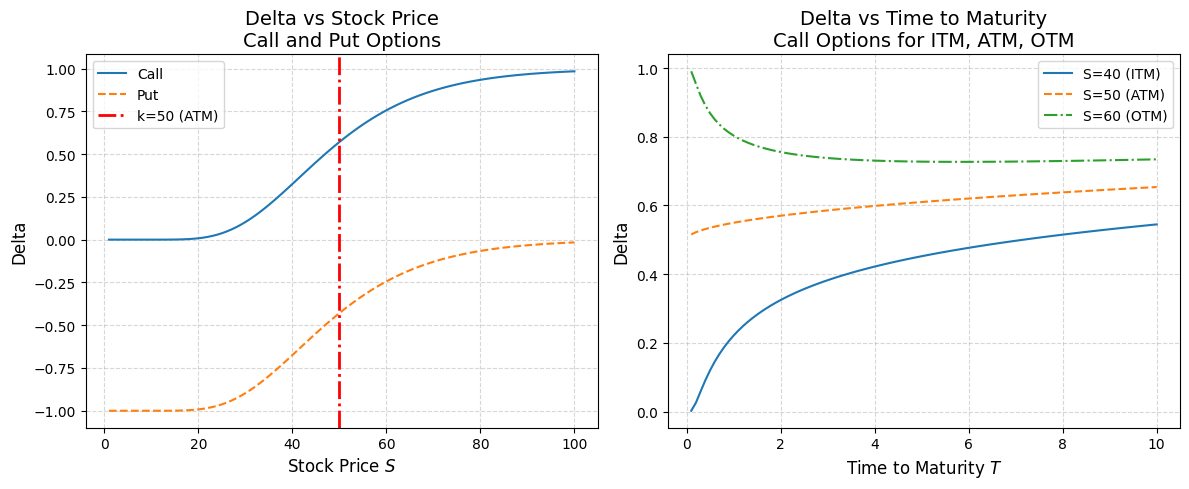

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from greeks import delta

# Parameters
stocks = np.linspace(1, 100, 100)
k, r, sigma = 50, 0, 0.25
maturities = np.linspace(0.1, 10, 100)

# Delta vs Stock Price (call and put)
deltas_call = delta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=2)
deltas_put  = delta(option_type='put',  s=stocks, k=k, r=r, sigma=sigma, T=2)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: Delta vs Stock Price
axes[0].plot(stocks, deltas_call, linestyle='-', label='Call')
axes[0].plot(stocks, deltas_put, linestyle='--', label='Put')
axes[0].set_xlabel('Stock Price $S$', fontsize=12)
axes[0].set_ylabel('Delta', fontsize=12)
axes[0].set_title('Delta vs Stock Price\nCall and Put Options', fontsize=14)
axes[0].axvline(x=50, color='red', linestyle='-.', linewidth=2, label='k=50 (ATM)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=10)

# Right panel: Delta vs Time to Maturity for ITM, ATM, OTM
stocks_example = [40, 50, 60]
linestyles = ['-', '--', '-.']
moneyness = ['ITM', 'ATM', 'OTM']
for s_val, linestyle, money in zip(stocks_example, linestyles, moneyness):
    deltas_T = delta(option_type='call', s=s_val, k=k, r=r, sigma=sigma, T=maturities)
    axes[1].plot(maturities, deltas_T, linestyle=linestyle, label=f'S={s_val} ({money})')

axes[1].set_xlabel('Time to Maturity $T$', fontsize=12)
axes[1].set_ylabel('Delta', fontsize=12)
axes[1].set_title('Delta vs Time to Maturity\nCall Options for ITM, ATM, OTM', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 1.2 Theta Variation

This subsection illustrates the behavior of **Theta** for European call and put options. We present two complementary plots side by side:

**Left Panel: Variation with Stock Price \($S$\)**  
- Shows Theta as a function of the underlying stock price for both call and put options.  
  - Fixed parameters: Strike price \($K$\), risk-free rate \($r$\), volatility \($\sigma$\), and time to maturity \($T$\).  
- Highlights the difference between the call and put option is equal to $r*K*exp(-r*T)$.  

**Right Panel: Variation with Time to Maturity \(T\)**  
- Shows Theta for call options at three levels of moneyness:  
  - **ITM:** \($S > K$\)  
  - **ATM:** \($S = K$\)  
  - **OTM:** \($S < K$\)  
- Illustrates how Theta evolves as the option approaches expiration, depending on how far in- or out-of-the-money it is.


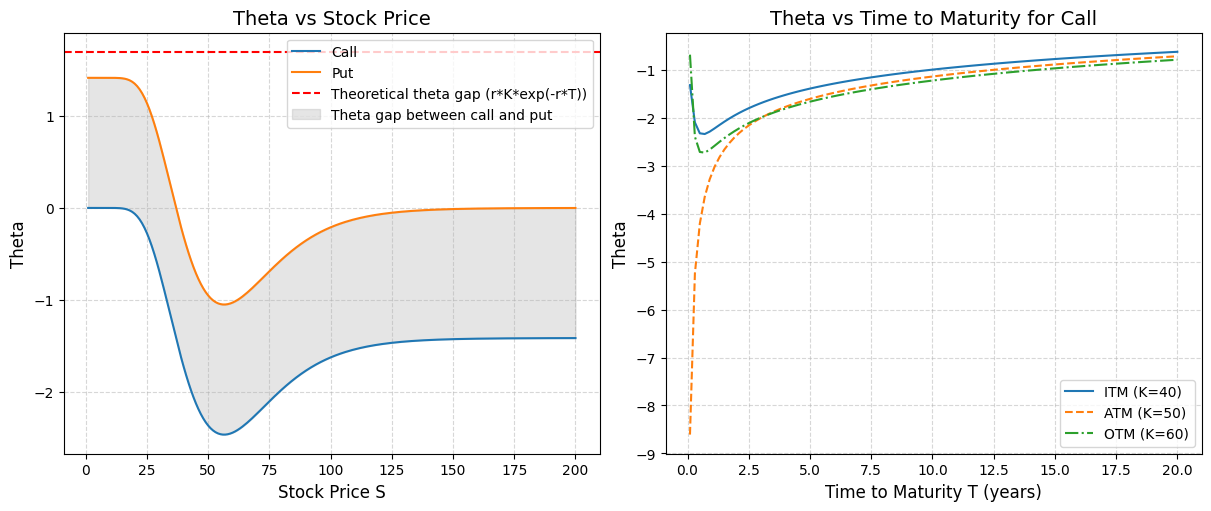

In [21]:
# Parameters
stocks = np.linspace(1, 200, 200)
k_vals = [40, 50, 60]  # for ITM, ATM, OTM
s_fixed = 50
r, sigma, T = 0.03, 0.25, 2

# Left: Theta vs Stock Price for Call and Put
thetas_call = theta(option_type='call', s=stocks, k=50, r=r, sigma=sigma, T=T)
thetas_put = theta(option_type='put', s=stocks, k=50, r=r, sigma=sigma, T=T)
theta_gap = r * k * np.exp(-r * T)

# Right: Theta vs Time to Maturity for Call at different moneyness
maturities = np.linspace(0.1, 20, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Left panel
ax = axes[0]
ax.plot(stocks, thetas_call, label='Call')
ax.plot(stocks, thetas_put, label='Put')
ax.axhline(y=theta_gap, color='r', linestyle='--', label='Theoretical theta gap (r*K*exp(-r*T))')
ax.fill_between(stocks, thetas_call, thetas_put, color='grey', alpha=0.2, label='Theta gap between call and put')
ax.set_xlabel('Stock Price S', fontsize=12)
ax.set_ylabel('Theta', fontsize=12)
ax.set_title('Theta vs Stock Price', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)

# Right panel
ax = axes[1]
for k, moneyness, linestyle in zip(k_vals, ['ITM','ATM','OTM'], ['-','--','-.']):
    thetas_call_T = theta(option_type='call', s=s_fixed, k=k, r=r, sigma=sigma, T=maturities)
    ax.plot(maturities, thetas_call_T, linestyle=linestyle, label=f'{moneyness} (K={k})')
ax.set_xlabel('Time to Maturity T (years)', fontsize=12)
ax.set_ylabel('Theta', fontsize=12)
ax.set_title('Theta vs Time to Maturity for Call', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)

plt.show()

/var/folders/d_/6y86tpf532z078fl9rsr03b40000gn/T/ipykernel_42261/335352181.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


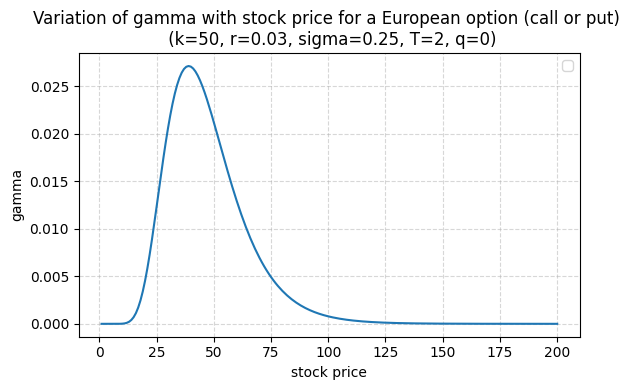

In [6]:
stocks = np.linspace(1,200,200)
k, r, sigma, T, q = 50, 0.03, 0.25, 2, 0

gammas = gamma(s=stocks, k=k, r=r, sigma=sigma, T=T)

plt.figure(figsize=(6,4))
plt.plot(stocks, gammas)
plt.ylabel('gamma')
plt.xlabel('stock price')
plt.title('Variation of gamma with stock price for a European option (call or put) \n (k=50, r=0.03, sigma=0.25, T=2, q=0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

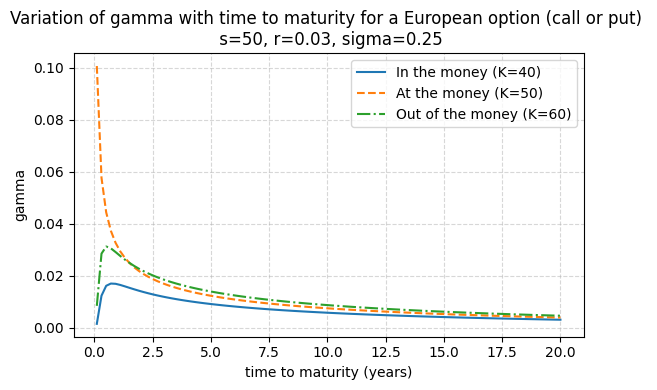

In [7]:
maturities = np.linspace(0.1,20,100)

plt.figure(figsize=(6,4))
for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    gammas = gamma(s=50, k=k, r=0.03, sigma=0.25, T=maturities)
    plt.plot(maturities, gammas, linestyle=linestyle, label=f'{moneyness} (K={k})')
    
plt.ylabel('gamma')
plt.xlabel('time to maturity (years)')
plt.title('Variation of gamma with time to maturity for a European option (call or put) \n s=50, r=0.03, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

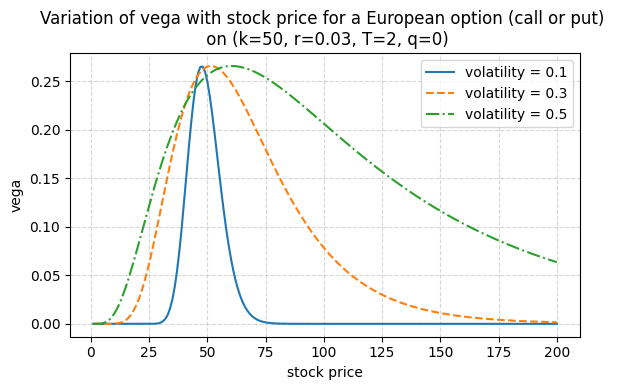

In [8]:
stocks = np.linspace(1,200,200)
k, r, T = 50, 0.03, 2

plt.figure(figsize=(6,4))
for sigma, linestyle in zip(
    [0.1, 0.3, 0.5],
    ['-','--','-.']
):
    vegas = vega(s=stocks, k=k, r=r, sigma=sigma, T=T)
    plt.plot(stocks, vegas, linestyle=linestyle, label=f'volatility = {sigma}')
plt.ylabel('vega')
plt.xlabel('stock price')
plt.title('Variation of vega with stock price for a European option (call or put) \n on (k=50, r=0.03, T=2, q=0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

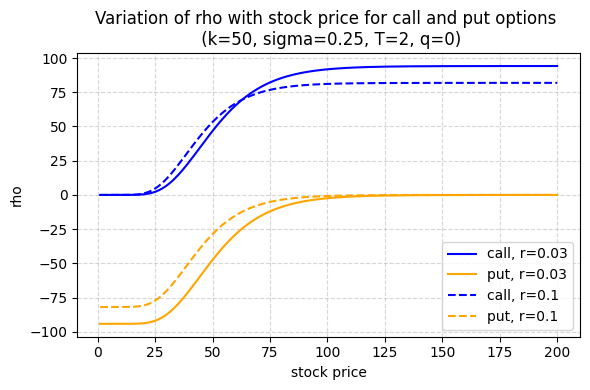

In [9]:
stocks = np.linspace(1,200,200)
k, sigma, T = 50, 0.25, 2

plt.figure(figsize=(6,4))
for r, linestyle in zip([0.03, 0.10], ['-','--']):
    rhos_call = rho(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
    rhos_put = rho(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

    plt.plot(stocks, rhos_call, linestyle=linestyle, color='blue', label=f'call, r={r}')
    plt.plot(stocks, rhos_put, linestyle=linestyle, color='orange', label=f'put, r={r}')

plt.ylabel('rho')
plt.xlabel('stock price')
plt.title('Variation of rho with stock price for call and put options \n (k=50, sigma=0.25, T=2, q=0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

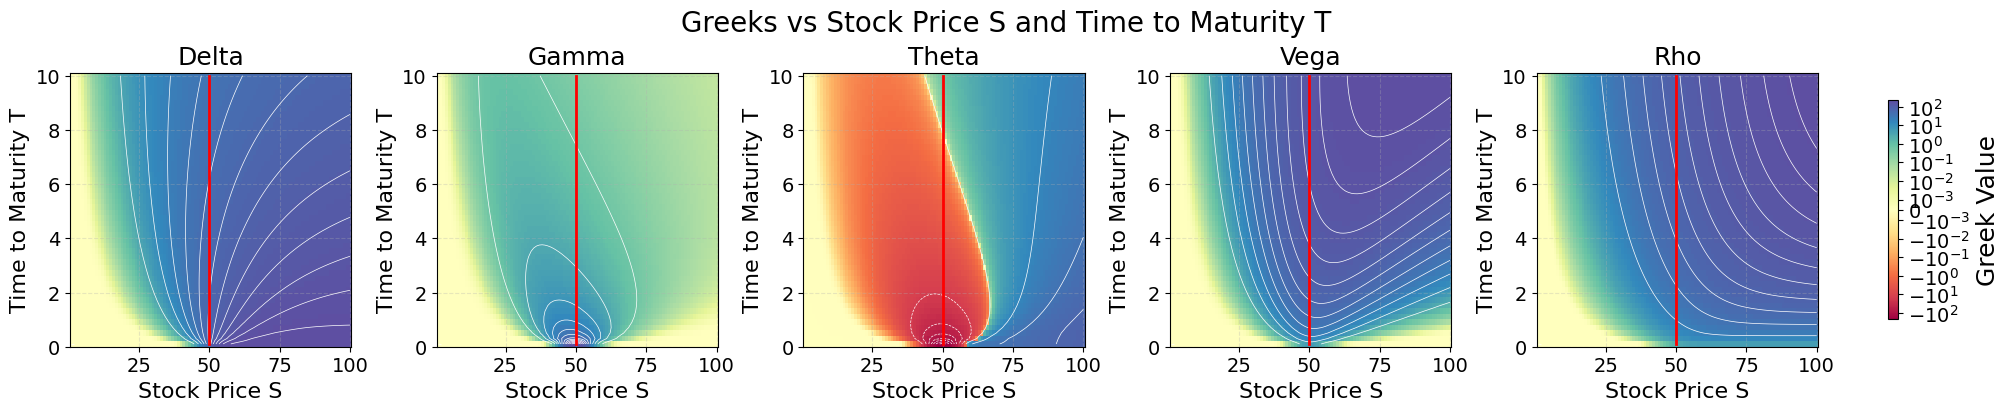

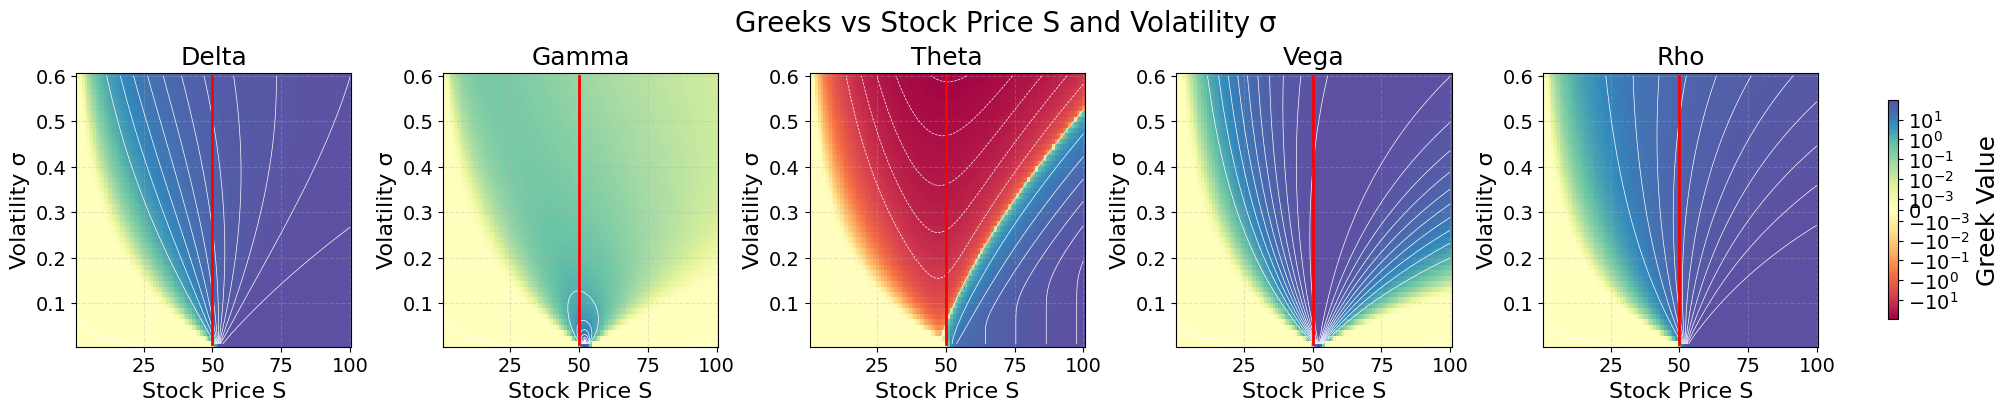

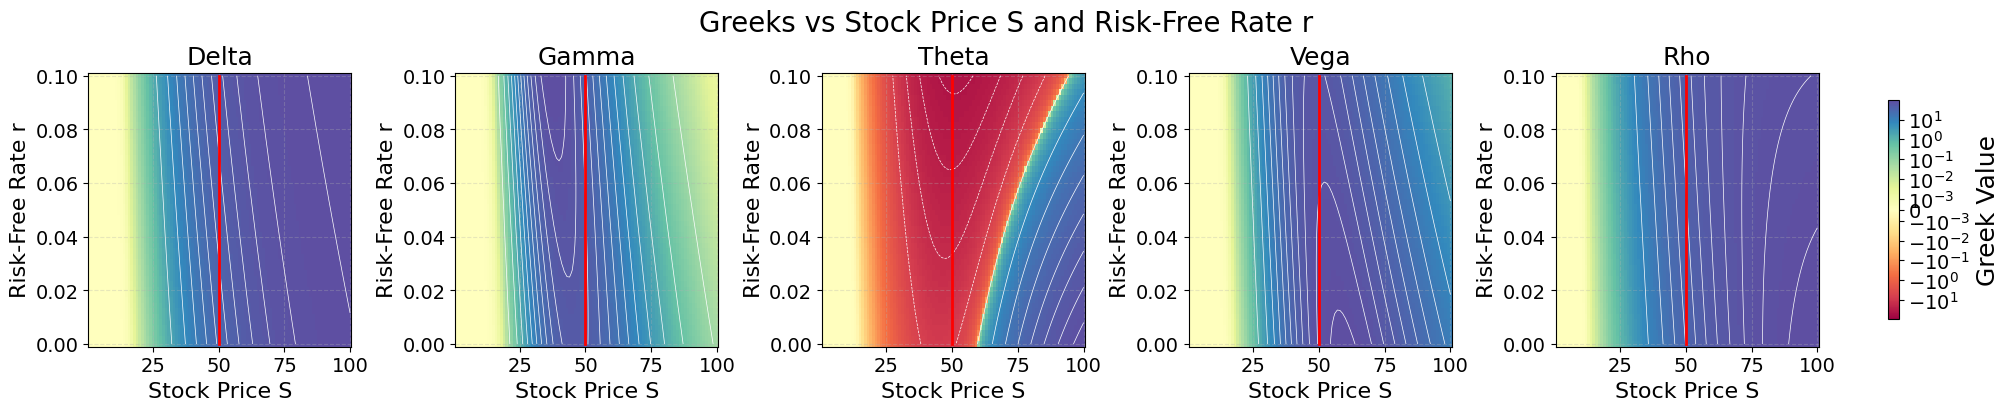

In [10]:

# Parameters
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10, 50)
volatilities = np.linspace(0.01, 0.6, 50)
rates = np.linspace(0.0, 0.1, 50)
k, q = 50, 0.05
sigma, r = 0.25, 0.03

# Define parameter pairs
param_pairs = [
    (stocks, maturities, 'Stock Price S', 'Time to Maturity T'),
    (stocks, volatilities, 'Stock Price S', 'Volatility σ'),
    (stocks, rates, 'Stock Price S', 'Risk-Free Rate r')
]

# Greek functions
greek_funcs = {
    'Delta': lambda s, T_var=None, sigma_var=None, r_var=None: delta(option_type='call', s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Gamma': lambda s, T_var=None, sigma_var=None, r_var=None: gamma(s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Theta': lambda s, T_var=None, sigma_var=None, r_var=None: theta(option_type='call', s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Vega':  lambda s, T_var=None, sigma_var=None, r_var=None: vega(s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Rho':   lambda s, T_var=None, sigma_var=None, r_var=None: rho(option_type='call', s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q)
}
# Loop over parameter pairs
for x_vals, y_vals, x_label, y_label in param_pairs:
    X, Y = np.meshgrid(x_vals, y_vals)

    # Compute all Greeks for this parameter pair
    greeks_data = {}
    for name, func in greek_funcs.items():
        if x_label == 'Stock Price S' and y_label == 'Time to Maturity T':
            greeks_data[name] = func(s=X, T_var=Y)
        elif x_label == 'Stock Price S' and y_label == 'Volatility σ':
            greeks_data[name] = func(s=X, sigma_var=Y)
        elif x_label == 'Stock Price S' and y_label == 'Risk-Free Rate r':
            greeks_data[name] = func(s=X, r_var=Y)

    # Create figure with 5 panels for Greeks
    fig, axes = plt.subplots(1, 5, figsize=(20,4), constrained_layout=True)
    fig.suptitle(f"Greeks vs {x_label} and {y_label}", fontsize=20)

    for ax, (g_name, Z) in zip(axes, greeks_data.items()):
        # SymLogNorm with per-Greek symmetric color limits
        abs_max = max(abs(Z.min()), abs(Z.max()))
        linthresh = 1e-3  # small linear region around zero
        pcm = ax.pcolormesh(
            X, Y, Z,
            cmap='Spectral',#'RdBu_r',
            shading='auto',
            norm=SymLogNorm(linthresh=linthresh, linscale=0.5, vmin=-abs_max, vmax=abs_max)
        )

        # Add contour lines
        ax.contour(X, Y, Z, colors='w', linewidths=0.5, levels=12)
        ax.set_title(g_name, fontsize=18)
        ax.set_xlabel(x_label, fontsize=16)
        ax.set_ylabel(y_label, fontsize=16)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=14)

        # ATM marker (S = K)
        atm_idx = np.argmin(np.abs(x_vals - k))
        ax.plot(x_vals[atm_idx]*np.ones_like(y_vals), y_vals, 'r', lw=2)

    # Shared colorbar
    cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), location='right', shrink=0.8, pad=0.03)
    cbar.set_label('Greek Value', fontsize=18)
    cbar.ax.tick_params(labelsize=14)

    plt.show()

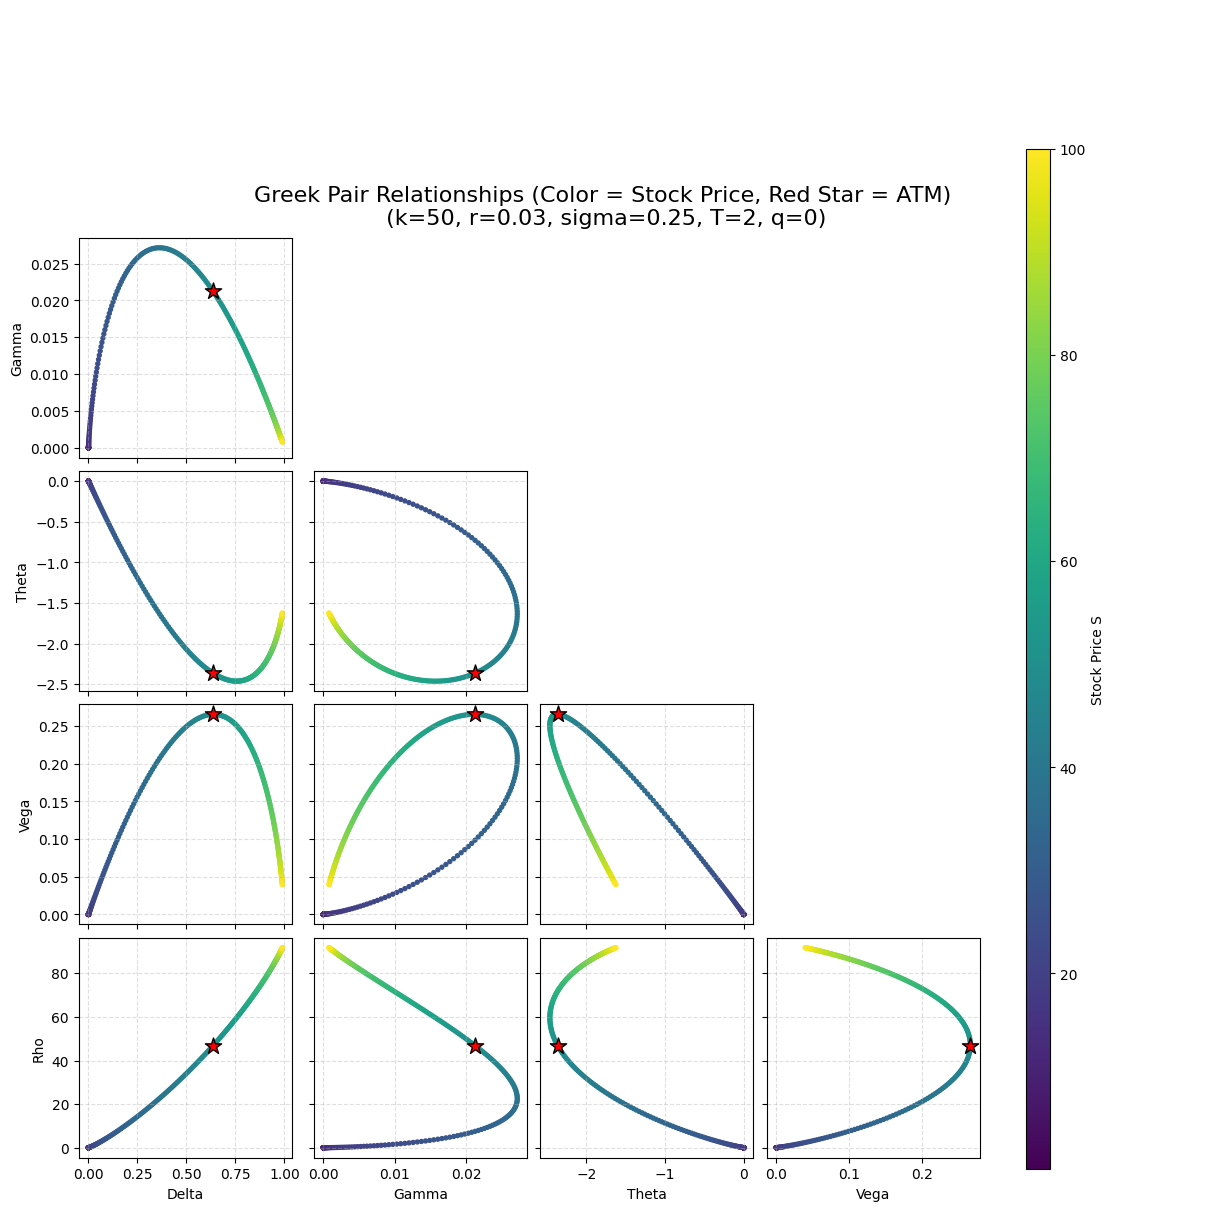

In [11]:
import numpy as np
import matplotlib.pyplot as plt

stocks = np.linspace(1, 100, 300)
k, r, sigma, T, q = 50, 0.03, 0.25, 2, 0

# Compute Greeks
greeks = {
    "Delta": delta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Gamma": gamma(s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Theta": theta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Vega":  vega(s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Rho":   rho(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T, q=q)
}

names = list(greeks.keys())
n = len(names)

atm_idx = np.argmin(np.abs(stocks - k))

fig, axes = plt.subplots(n, n, figsize=(12, 12), constrained_layout=True)

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        
        if i > j:  # lower triangle only
            x_name = names[j]
            y_name = names[i]
            
            sc = ax.scatter(greeks[x_name], greeks[y_name], c=stocks,
                cmap='viridis', s=8)

            ax.scatter(greeks[x_name][atm_idx], greeks[y_name][atm_idx], 
                       color='red', marker='*', s=150, edgecolor='k', zorder=5)
            
            ax.grid(True, linestyle='--', alpha=0.4)
            
            if i == n - 1:
                ax.set_xlabel(x_name)
            else:
                ax.set_xticklabels([])
                
            if j == 0:
                ax.set_ylabel(y_name)
            else:
                ax.set_yticklabels([])
                
        else:
            ax.axis("off")


cbar_ax = fig.add_axes([0.85, 0.03, 0.02, 0.85]) 
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Stock Price S")

fig.suptitle( "Greek Pair Relationships (Color = Stock Price, Red Star = ATM) \n (k=50, r=0.03, sigma=0.25, T=2, q=0) ", 
            fontsize=16, y=0.85)

plt.show()